In [1]:
import numpy as np               # numerical computing library (arrays, math)
import matplotlib.pyplot as plt  # plotting library
import scipy.integrate as spi    # scientific library — ODE solvers
import os                        # operating system interface
os.chdir(r'C:/Users/Giannis/.vscode/03_pharmacokinetics_simulator')

# One compartment model
# Drug enters bloodstream instantly (IV injection) and is eliminated at a constant rate
# ODE function — defines the rate of change of drug concentration
# solve_ivp calls this function repeatedly to integrate forward in time
# arguments must be (t, y, params) in this exact order for solve_ivp

def drug_elimination(t, C, ke):
    """
    C  = drug concentration in blood (mg/L)
    t  = time (hours)
    ke = elimination rate constant (1/hours)
    """
    dCdt = -ke * C  # first order elimination: rate proportional to concentration
    return dCdt     # solve_ivp needs the derivative returned

# Parameters
C0 = [100.0]                       # initial drug concentration — list required by solve_ivp
ke = 0.15                          # elimination rate constant (how fast drug leaves body)
t_span = (0, 48)                   # simulation window: start=0h, end=48h
t_eval = np.linspace(0, 48, 1000)  # 1000 evenly spaced time points to evaluate

# Solve ODE
solution = spi.solve_ivp(
    fun=drug_elimination,  # the ODE function to integrate
    t_span=t_span,         # time interval to solve over
    y0=C0,                 # initial condition (starting concentration)
    t_eval=t_eval,         # specific time points to record solution at
    args=(ke,),            # extra parameters passed to drug_elimination
    method='RK45'          # Runge-Kutta 4/5 — adaptive step size integrator
)

C = solution.y[0]   # extract concentration array from solution object
t = solution.t      # extract time array from solution object

# Half life
half_life = np.log(2) / ke  # t½ = ln(2)/ke — same formula as radioactive decay

print(f'Elimination rate: {ke} /hour')
print(f'Half life: {half_life:.1f} hours')
print(f'Initial concentration: {C0[0]} mg/L')
print(f'Concentration after 24h: {C[500]:.2f} mg/L')
print(f'Solver status: {solution.message}')  # confirms solver succeeded

Elimination rate: 0.15 /hour
Half life: 4.6 hours
Initial concentration: 100.0 mg/L
Concentration after 24h: 2.73 mg/L
Solver status: The solver successfully reached the end of the integration interval.


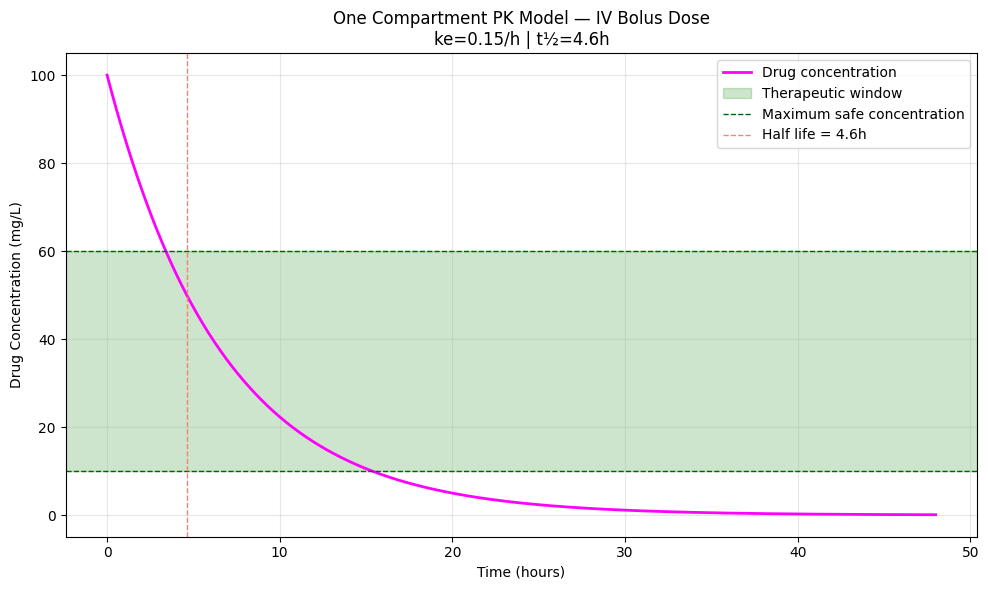

In [2]:
# Therapeutic window (safe drug concentration range)
C_min = 10.0   # minimum effective concentration (below = drug not working)
C_max = 60.0   # maximum safe concentration (above = toxic)

plt.figure(figsize=(10, 6))  # create figure, set size in inches

plt.plot(t, C, color='magenta', linewidth=2, label='Drug concentration')                                  # main concentration curve
plt.axhspan(C_min, C_max, alpha=0.2, color='green', label='Therapeutic window')                             # shade safe zone between C_min and C_max
plt.axhline(C_min, color='darkgreen', linestyle='--', linewidth=1)                                              # horizontal line at minimum effective concentration
plt.axhline(C_max, color='darkgreen', linestyle='--', linewidth=1, label='Maximum safe concentration')            # horizontal line at toxic level
plt.axvline(half_life, color='salmon', linestyle='--', linewidth=1, label=f'Half life = {half_life:.1f}h')  # vertical line at half life time
plt.xlabel('Time (hours)')                                                                                  # x axis label
plt.ylabel('Drug Concentration (mg/L)')                                                                     # y axis label
plt.title(f'One Compartment PK Model — IV Bolus Dose\n'
          f'ke={ke}/h | t½={half_life:.1f}h')                                                               # plot title with key parameters

plt.legend()                                                       # show legend box
plt.grid(True, alpha=0.3)                                          # add light grid for readability
plt.tight_layout()                                                 # auto adjust spacing so nothing overlaps
plt.savefig('results/01_one_compartment.png', bbox_inches='tight') # save plot to results folder
plt.show()                                                         # display plot in notebook